In [2]:
from pathlib import Path

from data.data_prep import DataPrep
from config.base import BaseConfig
from data.params_cdc import CDCParamsLoader
from engine.joint_runner import (
    run_uncertainty
)
from core.utils import load_results
from models.sbm.estimation.transforms import FeatureTransformer
from models.sbm.prediction.predictor import Predictor
import numpy as np

In [3]:
data = load_results(Path("sem_mc_results.npz"))

unit_map = {val: i for i, val in enumerate(data['unit_order'])}

def get_index(unit_id):
    return unit_map.get(unit_id)

idx = get_index('CA')
J = data['Jmeans_stack'][:, idx, :, :]

def spectral_radius(J):
    eigvals = np.linalg.eigvals(J)
    return np.max(np.abs(eigvals))

rhos = np.array([spectral_radius(Ji) for Ji in J])

transformer = FeatureTransformer()
predictor = Predictor()

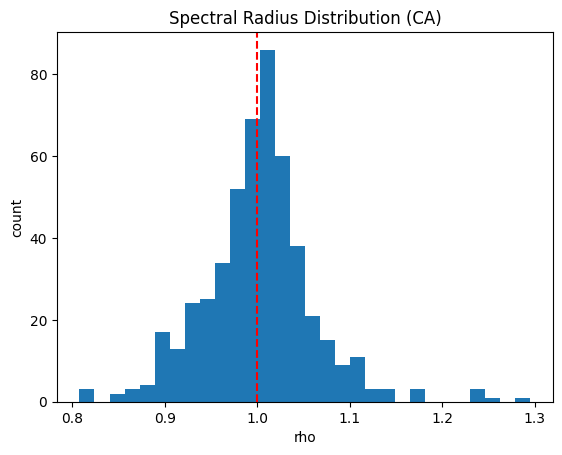

In [4]:
import matplotlib.pyplot as plt

plt.hist(rhos, bins=30)
plt.axvline(1.0, color='red', linestyle='--')
plt.title("Spectral Radius Distribution (CA)")
plt.xlabel("rho")
plt.ylabel("count")
plt.show()

In [5]:
low_idx  = rhos <= np.quantile(rhos, 0.33)
mid_idx  = (rhos > np.quantile(rhos, 0.33)) & (rhos <= np.quantile(rhos, 0.66))
high_idx = rhos > np.quantile(rhos, 0.66)

In [31]:
def simulate_group(J_subset, X0, u, n_steps, predictor):
    Ys = []
    
    for J_k in J_subset:
        Ypred, _ = predictor.predict_trajectory(J_k, X0, u, n_steps)
        Ys.append(Ypred)
    
    return np.array(Ys)  # shape: (n_samples_group, m, T)

J_low  = J[low_idx]
J_mid  = J[mid_idx]
J_high = J[high_idx]

Y = data['Ypreds_stack'][:, idx, :, :]  # (n_samples, m, T)
Y_mean = Y.mean(axis=0)
X, _ = transformer.transform(Y_mean)  # shape: (n_features,)
X0 = X[:, 0]  # initial state
u = np.zeros_like(X0)  # no interventions
n_steps = Y.shape[2] + 50


Y_low  = simulate_group(J_low,  X0, u, n_steps, predictor)
Y_mid  = simulate_group(J_mid,  X0, u, n_steps, predictor)
Y_high = simulate_group(J_high, X0, u, n_steps, predictor)

/Users/meibinchen/Documents/GitHub/EEE-SD-Model-2026/core/math/transforms.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [ ]:
v_names = data['v_names']

def vidx(name):
    v_names = {val: i for i, val in enumerate(data['v_names'])
               }
    return v_names.get(name, -1)

i_prep = vidx("prep_used")
i_test = vidx("hivtest12")
i_hcp  = vidx("seehcp")
i_ahs  = vidx("stigma_ahs")
i_gss = vidx("stigma_gss")
i_fam = vidx("stigma_family")
i_risk = vidx("risk_behavior")
i_out = vidx("out_hcp")

def summarize(Y):
    med = np.median(Y, axis=0)
    lo  = np.percentile(Y, 2.5, axis=0)
    hi  = np.percentile(Y, 97.5, axis=0)
    return med, lo, hi

low_med, low_lo, low_hi = summarize(Y_low)
mid_med, mid_lo, mid_hi = summarize(Y_mid)
high_med, high_lo, high_hi = summarize(Y_high)

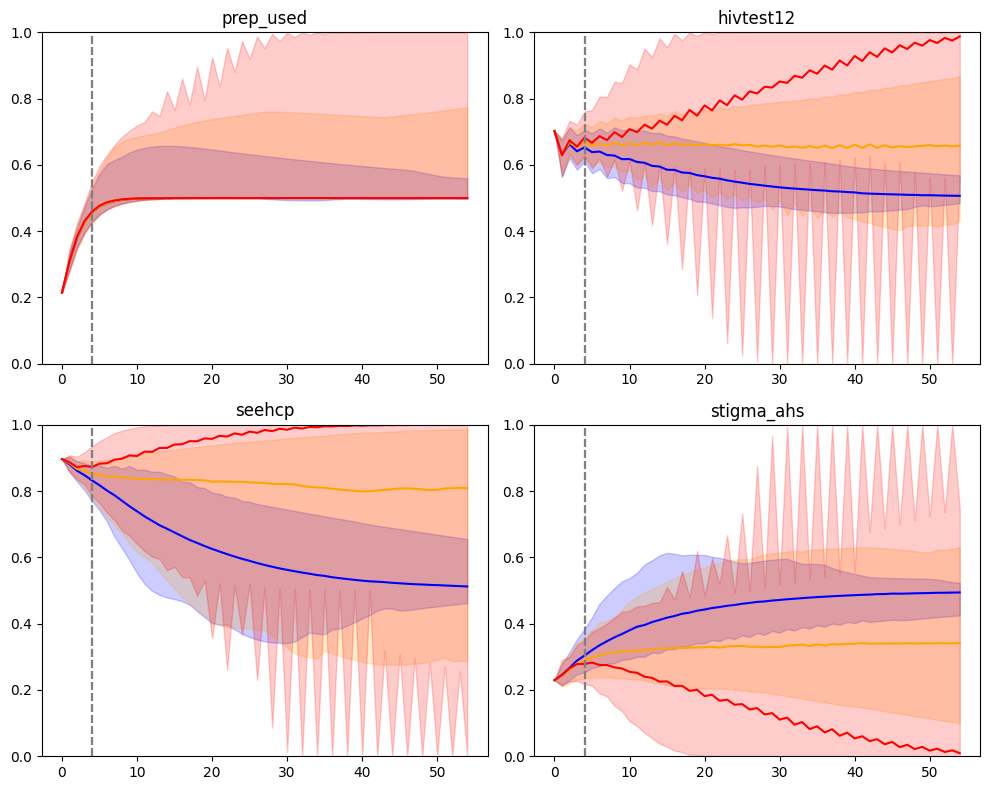

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))


vars_to_plot = [
    ("prep_used", i_prep),
    ("hivtest12", i_test),
    ("seehcp", i_hcp),
    ("stigma_ahs", i_ahs),
    ("stigma_gss", i_gss),
    ("stigma_family", i_fam),
    ("risk_behavior", i_risk),
    ("out_hcp", i_out),
]

t = np.arange(Y.shape[2] + 50) # time steps

for ax, (name, idx_var) in zip(axes.flatten(), vars_to_plot):
    for med, lo, hi, color, label in [
        (low_med, low_lo, low_hi, "blue", "Low rho"),
        (mid_med, mid_lo, mid_hi, "orange", "Mid rho"),
        (high_med, high_lo, high_hi, "red", "High rho"),
    ]:
        ax.plot(t, med[idx_var], color=color)
        ax.fill_between(t, lo[idx_var], hi[idx_var], alpha=0.2, color=color)
        ax.set_ylim(0, 1)
        ax.axvline(4, color='gray', linestyle='--', label='Target')
    
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path

from data.data_prep import DataPrep
from config.base import BaseConfig
from data.params_cdc import CDCParamsLoader
from engine.joint_runner import (
    load_sem_samples,
    build_units_dict,
    run_uncertainty,
    load_results
)

# 1) Inputs
config = BaseConfig()
prepared = DataPrep(config).prepare_inputs()
units = build_units_dict(prepared.units)

cdc_loader = CDCParamsLoader(
    Path("cdc_posteriors.nc"),
    Path("trans_results.npz"),
)

# SEM posterior samples npz (must contain: Ypreds_stack, unit_order, v_names, ts)
sem_samples = load_sem_samples(Path("sem_mc_results.npz"))  # change filename if needed

# 2) Run a small MC test first
out_u = run_uncertainty(
    sem_samples=sem_samples,
    cdc_params_loader=cdc_loader,
    units=units,
    unit_ids=["CA"],      # start with one unit
    n_samples=100,        # small smoke test
    seed=123,
    show_progress=True,
)

# 3) Check results
u_ca = out_u["CA"]
print("n_samples:", u_ca.n_samples)
print("years:", u_ca.years)
print("diagnosed quantiles (2.5%, 50%, 97.5%):")
print(u_ca.get_quantiles("diagnosed"))


MC CA:   0%|          | 0/100 [00:00<?, ?it/s]


NameError: name 'sem_traj' is not defined

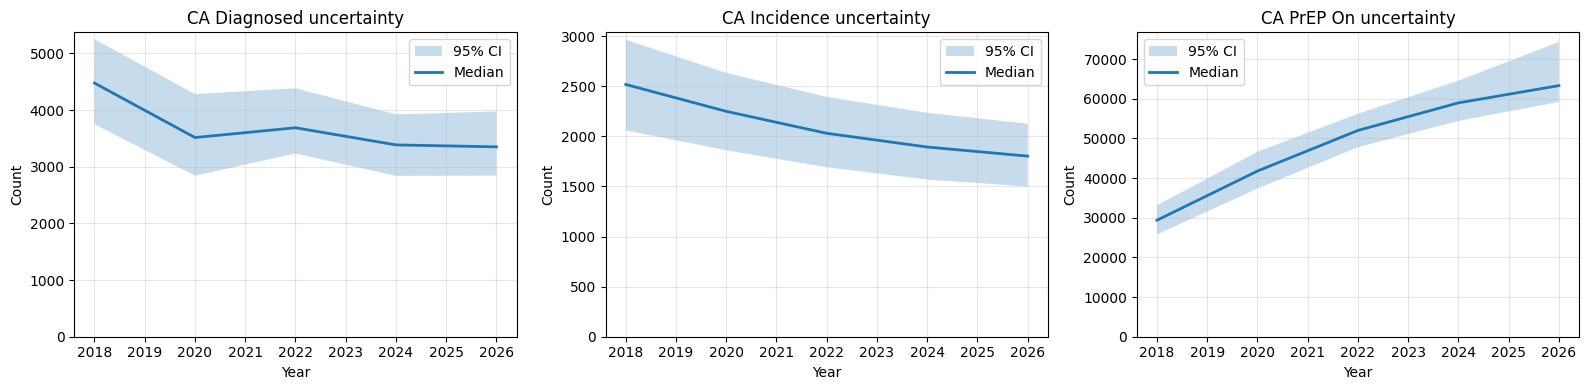

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from config.base import BaseConfig
from data.data_prep import DataPrep
from data.params_cdc import CDCParamsLoader
from engine.joint_runner import load_sem_samples, build_units_dict, run_uncertainty

# -----------------------------
# 1) Setup for 5-year forecast
# -----------------------------
uid = "CA"
n_forecast = 5

# Load SEM samples (already includes forecast horizon if generated that way)
sem_samples = load_sem_samples(Path("sem_samples.npz"))   # adjust filename if needed

# If your samples only include observed years, you'll need to regenerate SEM samples with +5 years.
print("SEMSamples shape:", sem_samples.samples.shape)  # (S,G,m,T)
print("SEMSamples years:", sem_samples.ts)

# Optional: force/validate target years as observed + 5
base = BaseConfig()
prepared = DataPrep(base).prepare_inputs()
years_obs = np.asarray(prepared.ts, dtype=float)
years_target = np.arange(years_obs[0], years_obs[-1] + n_forecast + 1)  # inclusive
print("Observed years:", years_obs)
print("Target years:", years_target)

# -----------------------------
# 2) Load CDC params + units
# -----------------------------
cdc_loader = CDCParamsLoader(
    Path("cdc_posteriors.nc"),
    Path("trans_results.npz"),
)
units = build_units_dict(prepared.units)

# -----------------------------
# 3) Run uncertainty
# -----------------------------
u_all = run_uncertainty(
    sem_samples=sem_samples,
    cdc_params_loader=cdc_loader,
    units=units,
    unit_ids=[uid],
    n_samples=500,
    seed=123,
    show_progress=True,
    cdc_years=years_target,   # remove this line if you want default = sem_samples.ts
)
u_ca = u_all[uid]

# -----------------------------
# 4) Raw CDC alignment helper
# -----------------------------
def align_raw_to_years(unit, indicator_name, years_tgt):
    if unit.cdc_names is None or indicator_name not in unit.cdc_names:
        return None
    vals = unit.get_cdc(indicator_name)
    if vals is None or unit.cdc_years is None:
        return None
    x = np.asarray(unit.cdc_years, dtype=float)
    y = np.asarray(vals, dtype=float)
    m = ~np.isnan(y)
    if m.sum() < 2:
        return None
    return np.interp(years_tgt, x[m], y[m])

unit = units[uid]
yrs = np.asarray(u_ca.years, dtype=float)

raw_map = {
    "diagnosed": "HIV diagnoses",
    "incidence": "Estimated HIV incidence (MSM)",
    "prep_on_count": "PrEP",
}

# -----------------------------
# 5) Plot uncertainty + raw
# -----------------------------
vars_to_plot = [
    ("diagnosed", "Diagnosed"),
    ("incidence", "Incidence"),
    ("prep_on_count", "PrEP On"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True)

for ax, (var, title) in zip(axes, vars_to_plot):
    q = u_ca.get_quantiles(var)

    ax.fill_between(yrs, q[0.025], q[0.975], alpha=0.25, label="95% CI")
    ax.plot(yrs, q[0.5], lw=2, label="Median")

    raw_name = raw_map[var]
    raw = align_raw_to_years(unit, raw_name, yrs)
    if raw is not None:
        # show observed points only up to available CDC years
        x_raw = np.asarray(unit.cdc_years, dtype=float)
        y_raw = np.asarray(unit.get_cdc(raw_name), dtype=float)
        m = ~np.isnan(y_raw)
        ax.scatter(x_raw[m], y_raw[m], s=35, label=f"Observed: {raw_name}", zorder=5)

    # forecast divider
    if len(years_obs) > 0:
        ax.axvline(years_obs[-1], ls="--", alpha=0.5, color="gray")

    ax.set_title(f"{uid} {title}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


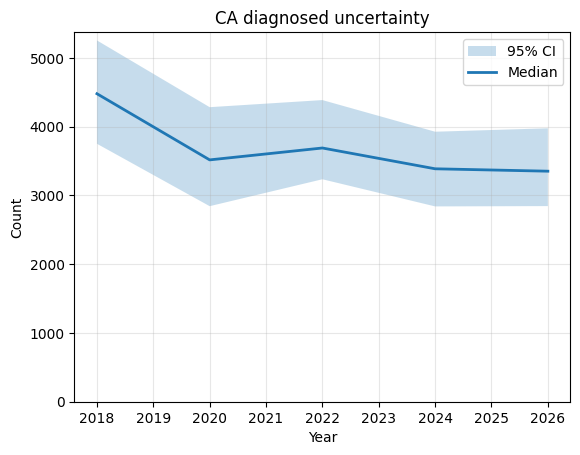

In [3]:
import matplotlib.pyplot as plt

q = u_ca.get_quantiles("diagnosed")
yrs = u_ca.years
plt.fill_between(yrs, q[0.025], q[0.975], alpha=0.25, label="95% CI")
plt.plot(yrs, q[0.5], lw=2, label="Median")
plt.title("CA diagnosed uncertainty")
plt.xlabel("Year")
plt.ylabel("Count")
plt.ylim(0, None)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


SEMSamples shape: (500, 59, 8, 5)
SEMSamples years: [2018. 2020. 2022. 2024. 2026.]
Observed years: [2018. 2020. 2022. 2024.]
Target years: [2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025. 2026. 2027. 2028. 2029.]


MC CA: 100%|██████████| 500/500 [00:00<00:00, 6140.41it/s]


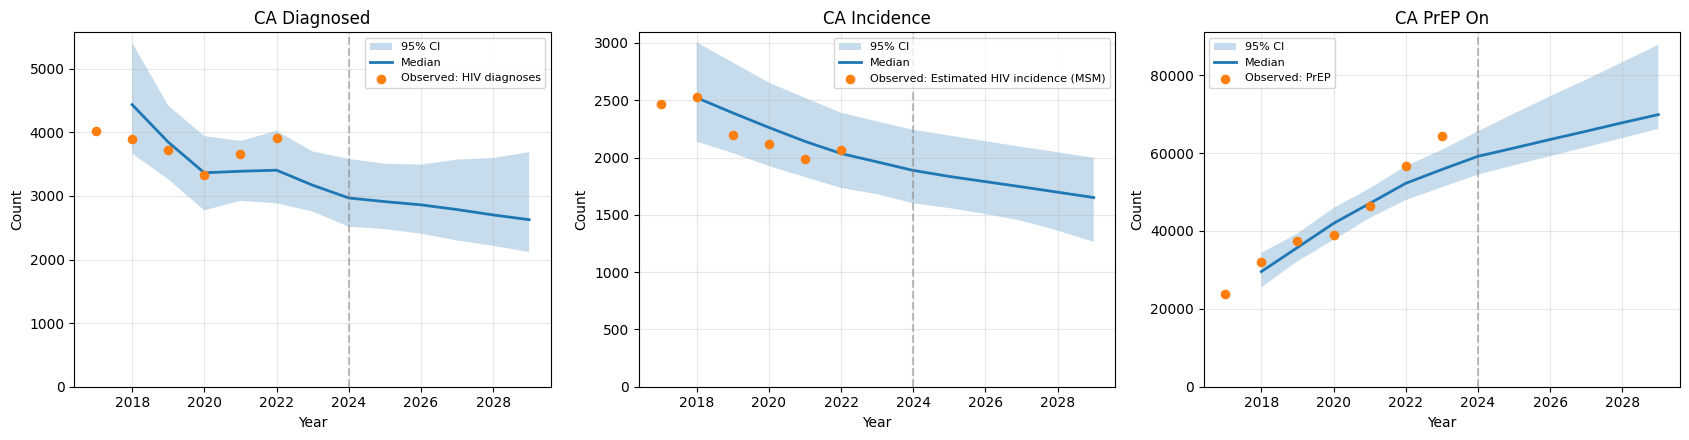

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from config.base import BaseConfig
from data.data_prep import DataPrep
from data.params_cdc import CDCParamsLoader
from engine.joint_runner import load_sem_samples, build_units_dict, run_uncertainty

# -----------------------------
# 1) Setup for 5-year forecast
# -----------------------------
uid = "CA"
n_forecast = 5

# Load SEM samples (already includes forecast horizon if generated that way)
sem_samples = load_sem_samples(Path("sem_mc_results.npz"))   # adjust filename if needed

# If your samples only include observed years, you'll need to regenerate SEM samples with +5 years.
print("SEMSamples shape:", sem_samples.samples.shape)  # (S,G,m,T)
print("SEMSamples years:", sem_samples.ts)

# Optional: force/validate target years as observed + 5
base = BaseConfig()
prepared = DataPrep(base).prepare_inputs()
years_obs = np.asarray(prepared.ts, dtype=float)
years_target = np.arange(years_obs[0], years_obs[-1] + n_forecast + 1)  # inclusive
print("Observed years:", years_obs)
print("Target years:", years_target)

# -----------------------------
# 2) Load CDC params + units
# -----------------------------
cdc_loader = CDCParamsLoader(
    Path("cdc_posteriors.nc"),
    Path("trans_results.npz"),
)
units = build_units_dict(prepared.units)

# -----------------------------
# 3) Run uncertainty
# -----------------------------
u_all = run_uncertainty(
    sem_samples=sem_samples,
    cdc_params_loader=cdc_loader,
    units=units,
    unit_ids=[uid],
    n_samples=500,
    seed=123,
    show_progress=True,
    cdc_years=years_target,   # remove this line if you want default = sem_samples.ts
)
u_ca = u_all[uid]

# -----------------------------
# 4) Raw CDC alignment helper
# -----------------------------
def align_raw_to_years(unit, indicator_name, years_tgt):
    if unit.cdc_names is None or indicator_name not in unit.cdc_names:
        return None
    vals = unit.get_cdc(indicator_name)
    if vals is None or unit.cdc_years is None:
        return None
    x = np.asarray(unit.cdc_years, dtype=float)
    y = np.asarray(vals, dtype=float)
    m = ~np.isnan(y)
    if m.sum() < 2:
        return None
    return np.interp(years_tgt, x[m], y[m])

unit = units[uid]
yrs = np.asarray(u_ca.years, dtype=float)

raw_map = {
    "diagnosed": "HIV diagnoses",
    "incidence": "Estimated HIV incidence (MSM)",
    "prep_on_count": "PrEP",
}

# -----------------------------
# 5) Plot uncertainty + raw
# -----------------------------
vars_to_plot = [
    ("diagnosed", "Diagnosed"),
    ("incidence", "Incidence"),
    ("prep_on_count", "PrEP On"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True)

for ax, (var, title) in zip(axes, vars_to_plot):
    q = u_ca.get_quantiles(var)

    ax.fill_between(yrs, q[0.025], q[0.975], alpha=0.25, label="95% CI")
    ax.plot(yrs, q[0.5], lw=2, label="Median")

    raw_name = raw_map[var]
    raw = align_raw_to_years(unit, raw_name, yrs)
    if raw is not None:
        # show observed points only up to available CDC years
        x_raw = np.asarray(unit.cdc_years, dtype=float)
        y_raw = np.asarray(unit.get_cdc(raw_name), dtype=float)
        m = ~np.isnan(y_raw)
        ax.scatter(x_raw[m], y_raw[m], s=35, label=f"Observed: {raw_name}", zorder=5)

    # forecast divider
    if len(years_obs) > 0:
        ax.axvline(years_obs[-1], ls="--", alpha=0.5, color="gray")

    ax.set_title(f"{uid} {title}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


In [8]:
from models.shared.transforms import hazard_proxy
hazard_proxy(0.837)

np.float64(1.8140050781753745)

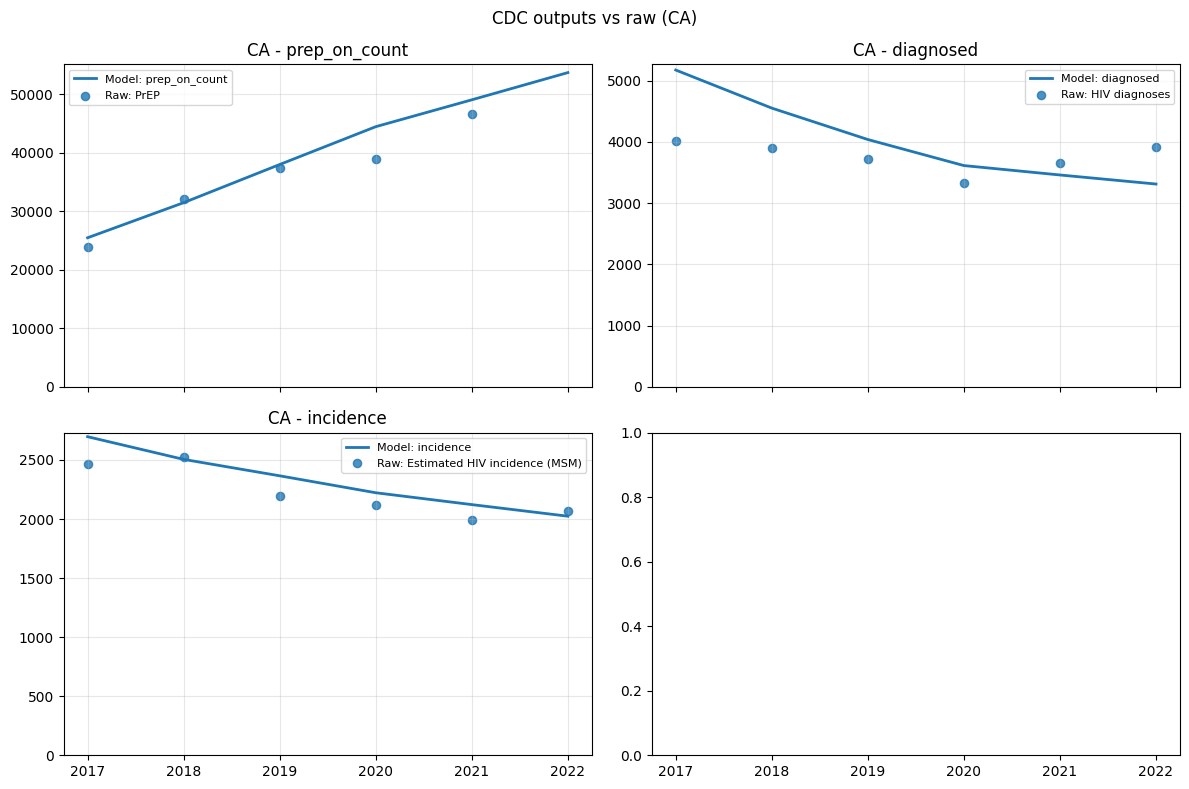

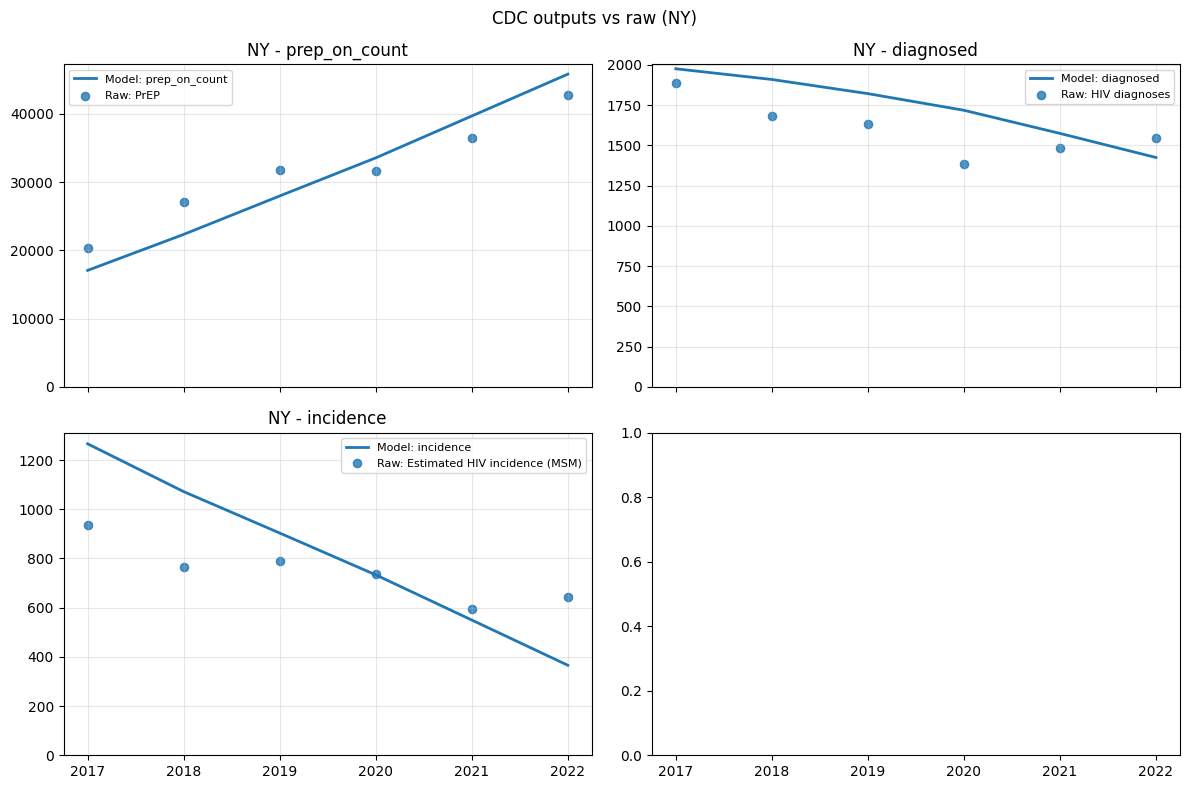

In [3]:
from pathlib import Path

from data.data_prep import DataPrep
from config.base import BaseConfig
from data.params_cdc import CDCParamsLoader
from engine.joint_runner import load_sem_output, build_units_dict, run_joint

# 1) Prepare data (for units + CDC inputs by geography)
config = BaseConfig()   # no "..."
prep = DataPrep(config)
prepared = prep.prepare_inputs()

# 2) Load SEM output + CDC posterior params
sem_output = load_sem_output(Path("output/output.pkl"))
cdc_loader = CDCParamsLoader(
    Path("cdc_posteriors.nc"),
    Path("trans_results.npz"),
)
units = build_units_dict(prepared.units)
unit_ids_to_run = ['CA', 'NY']

# 3) Run joint pipeline
joint_out = run_joint(sem_output, cdc_loader, units, unit_ids=unit_ids_to_run)

# 4) Access outputs
# print(joint_out.results["USA"].cdc_output.diagnosed)

import numpy as np
import matplotlib.pyplot as plt

# CDC model output -> raw CDC indicator mapping
raw_map = {
    "prep_on_count": "PrEP",
    "diagnosed": "HIV diagnoses",
    "incidence": "Estimated HIV incidence (MSM)",      # only if present in your CDC table
}

def align_raw(unit, indicator_name, years_tgt):
    vals = unit.get_cdc(indicator_name)
    if vals is None or unit.cdc_years is None:
        return None
    x = np.asarray(unit.cdc_years, dtype=float)
    y = np.asarray(vals, dtype=float)
    m = ~np.isnan(y)
    if m.sum() < 2:
        return None
    return np.interp(years_tgt, x[m], y[m])

for uid in unit_ids_to_run:
    jr = joint_out.results[uid]
    unit = units[uid]
    years = np.asarray(jr.cdc_output.years, dtype=float)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.ravel()

    for ax, out_name in zip(axes, ["prep_on_count", "diagnosed", "incidence"]):
        y_model = np.asarray(getattr(jr.cdc_output, out_name), dtype=float)
        ax.plot(years, y_model, lw=2, label=f"Model: {out_name}")
        ax.set_ylim(0, None)

        ind = raw_map[out_name]
        y_raw = align_raw(unit, ind, years)
        if y_raw is not None:
            ax.scatter(years, y_raw, s=35, alpha=0.8, label=f"Raw: {ind}")

        ax.set_title(f"{uid} - {out_name}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(f"CDC outputs vs raw ({uid})")
    fig.tight_layout()
    plt.show()



In [ ]:
from data.params_cdc import CDCParamsLoader
from pathlib import Path

loader = CDCParamsLoader(
    nc_path=Path("full_hierarchical_python_mode_v10.nc"),
    trans_npz_path=Path("trans_results.npz"),
)

print("Geos:", loader.geo_names[:5], "...")
print("N samples:", loader.n_samples)

params = loader.load_point_estimates('USA')
print(f"USA params: beta={params.beta:.4f}, kdx={params.kdx:.4f}, U0={params.U0:.1f}")

Geos: [np.str_('USA'), np.str_('CT'), np.str_('MA'), np.str_('ME'), np.str_('NH')] ...
N samples: 2000
USA params: beta=0.0363, kdx=0.4086, U0=218546.4


ts_obs: [2018 2020 2022 2024]
ts_rolling: [2018 2020 2022 2024 2026]
ts_trajectory: [2018 2020 2022 2024 2026 2028 2030 2032 2034]


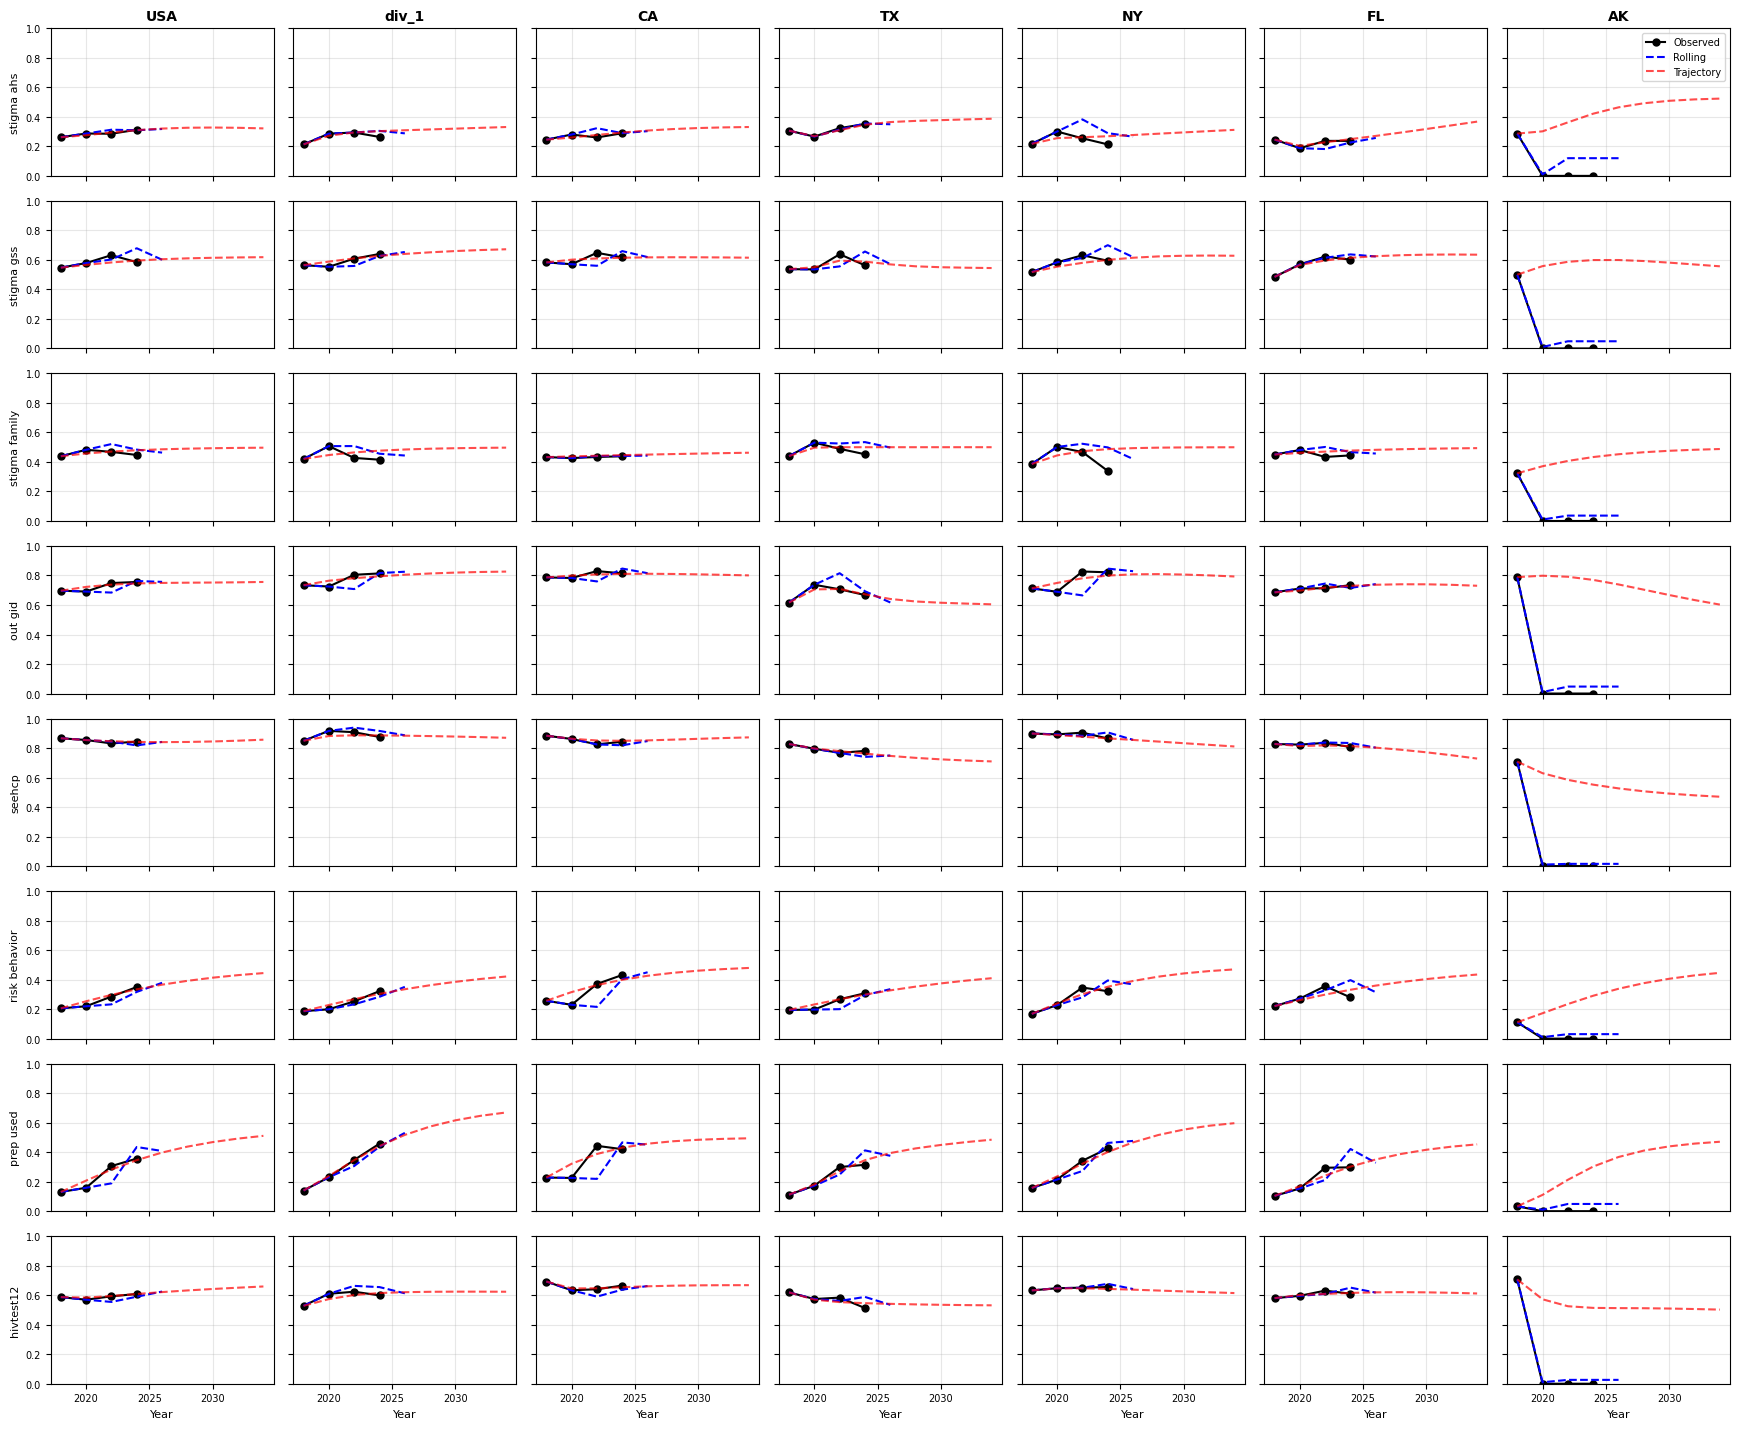

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("output/output.pkl", "rb") as f:
    output = pickle.load(f)

fit_results = output.fit
pred_results = output.predictions

units_to_plot = ["USA", "div_1", "CA", "TX", "NY", "FL", "AK"]

ts = np.array(fit_results.ts)
v_names = fit_results.v_names
m = len(v_names)
n_units = len(units_to_plot)
T_obs = len(ts)
dt = ts[1] - ts[0] if len(ts) > 1 else 2

# Time axes
ts_rolling = np.append(ts, ts[-1] + dt)  # T+1 points

pred_usa = pred_results.results["USA"]
n_total = pred_usa.Ypred_trajectory.shape[1]
ts_trajectory = ts[0] + dt * np.arange(n_total)  # Starts at first observed

print(f"ts_obs: {ts}")
print(f"ts_rolling: {ts_rolling}")
print(f"ts_trajectory: {ts_trajectory}")

fig, axes = plt.subplots(
    nrows=m,
    ncols=n_units,
    figsize=(2.5 * n_units, 1.8 * m),
    sharex=True,
    sharey="row",
)

for col, unit_id in enumerate(units_to_plot):
    fit_res = fit_results.results.get(unit_id)
    pred_res = pred_results.results.get(unit_id)

    if fit_res is None:
        print(f"Skipping {unit_id}")
        continue

    Ybar = fit_res.Ybar
    Ypred_rolling = pred_res.Ypred_rolling if pred_res else None
    Ypred_trajectory = pred_res.Ypred_trajectory if pred_res else None

    for row, var in enumerate(v_names):
        ax = axes[row, col]

        # Observed
        ax.plot(ts, Ybar[row, :], "ko-", ms=5, lw=1.5, label="Observed")

        # Rolling (one-step ahead using observed X)
        if Ypred_rolling is not None:
            ax.plot(ts_rolling, Ypred_rolling[row, :], "b--", lw=1.5, label="Rolling")

        # Trajectory (recursive simulation from X0)
        if Ypred_trajectory is not None:
            ax.plot(ts_trajectory, Ypred_trajectory[row, :], "r--", lw=1.5, alpha=0.7, label="Trajectory")

        if row == 0:
            ax.set_title(unit_id, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(var.replace("_", " "), fontsize=8)
        if row == m - 1:
            ax.set_xlabel("Year", fontsize=8)

        ax.set_ylim(0, 1)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

axes[0, -1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
# plt.savefig("output/test_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fit_usa = fit_results.results["USA"]

# J_sequence shape: (m, m, T)
J_sequence = fit_usa.J
print(f"J_sequence shape: {J_sequence.shape}")

# Last J from rolling sequence
J_rolling_last = J_sequence[:, :, -1]
print(f"\nJ_rolling_last (J[:,:,-1]):")
print(J_rolling_last)

# What J is used for trajectory?
# In runner: J_final = fit.J[:, :, -1]
J_trajectory = J_sequence[:, :, -1]
print(f"\nJ_trajectory (same as above):")


print(f"\nAre they the same? {np.allclose(J_rolling_last, J_trajectory)}")

J_sequence shape: (8, 8, 4)

J_rolling_last (J[:,:,-1]):
[[ 1.          0.0027325   0.06904453  0.16639955 -0.006597    0.
   0.         -0.13747356]
 [ 0.          1.          0.          0.02969859  0.          0.
   0.          0.        ]
 [ 0.          0.          1.          0.          0.          0.
   0.          0.        ]
 [-0.09617492  0.          0.          1.          0.          0.
   0.          0.0165467 ]
 [-0.07750493  0.          0.          0.          1.          0.
   0.1170779   0.10076782]
 [ 0.          0.          0.          0.          0.          1.
   0.          0.        ]
 [-0.05850038  0.          0.          0.          0.21402177  0.
   1.          0.        ]
 [ 0.          0.          0.          0.03361809  0.0328297   0.03021394
   0.01770375  1.        ]]

J_trajectory (same as above):
[[ 1.          0.0027325   0.06904453  0.16639955 -0.006597    0.
   0.         -0.13747356]
 [ 0.          1.          0.          0.02969859  0.          0.


In [33]:
import pandas as pd 
pd.DataFrame(J_trajectory, index=v_names, columns=v_names)

,stigma_ahs,stigma_gss,stigma_family,out_gid,seehcp,risk_behavior,prep_used,hivtest12
stigma_ahs,1.000000,0.002732,0.069045,0.166400,-0.006597,0.000000,0.000000,-0.137474
stigma_gss,0.000000,1.000000,0.000000,0.029699,0.000000,0.000000,0.000000,0.000000
stigma_family,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
out_gid,-0.096175,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.016547
seehcp,-0.077505,0.000000,0.000000,0.000000,1.000000,0.000000,0.117078,0.100768
risk_behavior,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
prep_used,-0.058500,0.000000,0.000000,0.000000,0.214022,0.000000,1.000000,0.000000
hivtest12,0.000000,0.000000,0.000000,0.033618,0.032830,0.030214,0.017704,1.000000


In [ ]:
        sign_matrix = np.array([
                [0, 1, 1, 1, -1, 0, 0, -1],
                [0, 0, 0, 1, 0, 0, 0, 0],
                [0, 1, 0, 0, 0, 0, 0, 0],
                [-1, 0, 0, 0, 0, 1, 0, 1],
                [-1, 0, 0, 0, 0, 0, 1, 1],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [-1, 0, 0, 1, 1, 1, 0, 1],
                [0, 0, 0, 1, 1, 1, 1, 0]
            ])

NameError: name 'data' is not defined

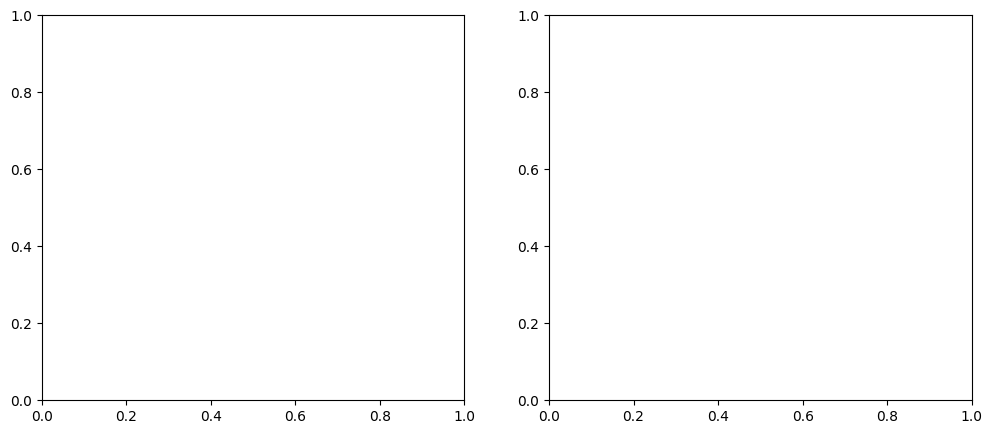

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im = ax.imshow(data.M, cmap='Blues')
ax.set_xticks(range(len(data.v_names)))
ax.set_yticks(range(len(data.v_names)))
ax.set_xticklabels(data.v_names, rotation=45, ha='right')
ax.set_yticklabels(data.v_names)
ax.set_title('M (allowed relationships)')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(data.sign_mask, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(data.v_names)))
ax.set_yticks(range(len(data.v_names)))
ax.set_xticklabels(data.v_names, rotation=45, ha='right')
ax.set_yticklabels(data.v_names)
ax.set_title('sign_mask (expected directions)')
plt.colorbar(im, ax=ax)

plt.tight_layout()
# plt.savefig("output/M_and_sign_mask.png", dpi=150)
plt.show()

In [ ]:
from models.shared.intervention import StateIntervention

name_to_idx = {v: i for i, v in enumerate(data['v_names'])}
ahs_name = 'stigma_ahs'
if ahs_name not in name_to_idx:
    raise ValueError(f"{ahs_name} not found in v_names: {list(name_to_idx.keys())}")

i_ahs = name_to_idx[ahs_name]
T_obs = Y.shape[2]
start_t = T_obs
end_t = min(T_obs + 10, n_steps - 1)

iv_ahs = [
    StateIntervention(
        var_idx=i_ahs,
        start_t=start_t,
        end_t=end_t,
        delta=-0.20,
        mode='linear',
        space='prob',
    )
]

print(f'Applying intervention on {ahs_name} from t={start_t} to t={end_t}')


In [ ]:
def simulate_group_with_iv(J_subset, X0, u, n_steps, predictor, interventions):
    Ys = []
    for J_k in J_subset:
        Ypred, _ = predictor.predict_trajectory(
            J_k,
            X0,
            u,
            n_steps,
            state_interventions=interventions,
            rel_interventions=None,
        )
        Ys.append(Ypred)
    return np.array(Ys)

Y_low_iv  = simulate_group_with_iv(J_low,  X0, u, n_steps, predictor, iv_ahs)
Y_mid_iv  = simulate_group_with_iv(J_mid,  X0, u, n_steps, predictor, iv_ahs)
Y_high_iv = simulate_group_with_iv(J_high, X0, u, n_steps, predictor, iv_ahs)

low_med_iv, low_lo_iv, low_hi_iv = summarize(Y_low_iv)
mid_med_iv, mid_lo_iv, mid_hi_iv = summarize(Y_mid_iv)
high_med_iv, high_lo_iv, high_hi_iv = summarize(Y_high_iv)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

vars_to_plot = [
    ('stigma_ahs', i_ahs),
    ('seehcp', i_hcp),
    ('prep_used', i_prep),
    ('hivtest12', i_test),
]

t = np.arange(n_steps)

groups = [
    ('Low rho',  'tab:blue',   (low_med,  low_lo,  low_hi),  (low_med_iv,  low_lo_iv,  low_hi_iv)),
    ('Mid rho',  'tab:orange', (mid_med,  mid_lo,  mid_hi),  (mid_med_iv,  mid_lo_iv,  mid_hi_iv)),
    ('High rho', 'tab:red',    (high_med, high_lo, high_hi), (high_med_iv, high_lo_iv, high_hi_iv)),
]

for ax, (name, idx_var) in zip(axes.flatten(), vars_to_plot):
    for label, color, base, iv in groups:
        med, lo, hi = base
        med_iv, lo_iv, hi_iv = iv

        ax.plot(t, med[idx_var], color=color, lw=2, label=f'{label} baseline')
        ax.fill_between(t, lo[idx_var], hi[idx_var], alpha=0.12, color=color)

        ax.plot(t, med_iv[idx_var], color=color, lw=2, ls='--', label=f'{label} + AHS intervention')

    ax.axvline(T_obs, color='gray', linestyle='--', label='Forecast start')
    ax.set_title(name)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
# keep legend compact and unique
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), fontsize=7, loc='best')

plt.tight_layout()
plt.show()
